# Part B - Data Cleaning, Embedding, Knowledge Graph & Reflection
## Amunra Advisors LLP - AI Engineer Assessment


In [1]:
# B1 - Data Cleaning

import csv, re
from datetime import datetime


In [2]:
# Load raw messy trades
raw_trades = []
with open("part_b_trades_messy.csv") as f:
    raw_trades = list(csv.DictReader(f))
print(f"Loaded {len(raw_trades)} raw trades")
print("Columns:", list(raw_trades[0].keys()))


Loaded 20 raw trades
Columns: ['trade_id', 'date', 'fund_name', 'instrument_name', 'exchange', 'direction', 'qty', 'price', 'instrument_type', 'sector', 'broker', 'custodian', 'ucc_code', 'notes']


In [3]:
# ── Canonical master tables ───────────────────────────────────────────────────

# instrument_master: NSE ticker → (canonical_name, canonical_sector)
# NSE ticker is the primary key - deterministic, not fuzzy.
instrument_master = {
    "RELIANCE":    ("Reliance Industries Ltd", "Oil & Gas"),
    "HDFCBANK":    ("HDFC Bank Ltd",           "Banking"),
    "ICICIBANK":   ("ICICI Bank Ltd",           "Banking"),
    "TCS":         ("Tata Consultancy Services","IT"),
    "INFY":        ("Infosys Ltd",              "IT"),
    "SBIN":        ("State Bank of India",      "Banking"),
    "PERSISTENT":  ("Persistent Systems Ltd",   "IT"),
    "COFORGE":     ("Coforge Ltd",              "IT"),
    "ZOMATO":      ("Zomato Ltd",               "Consumer Services"),
    "NIFTY25JAN25P":        ("NIFTY 25JAN25 Put",        "Index"),
    "NIFTY25JAN2523000PE":  ("NIFTY 25JAN25 23000 PE",   "Index"),
    "NIFTY27MAR2523500CE":  ("NIFTY 27MAR25 23500 CE",   "Index"),
    "NIFTY27MAR2523500PE":  ("NIFTY 27MAR25 23500 PE",   "Index"),
}

# Tier 2: alias dict catches variants that don't match an NSE ticker directly
# (especially abbreviations like "RIL" and multi-word names)
alias_dict = {
    # Reliance variants (5 confirmed in CSV)
    "RELIANCE INDUSTRIES LTD": "RELIANCE",
    "RELIANCE INDUSTRIES":     "RELIANCE",
    "RELIANCE INDS":           "RELIANCE",
    "RIL":                     "RELIANCE",
    "RELIANCE":                "RELIANCE",
    # HDFC Bank variants (4 confirmed in CSV)
    "HDFC BANK LIMITED":  "HDFCBANK",
    "HDFC BANK":          "HDFCBANK",
    "HDFC BANK LTD.":     "HDFCBANK",
    "HDFC BANK LTD":      "HDFCBANK",
    "HDFCBANK":           "HDFCBANK",
    # Other common forms already ticker-like
    # NIFTY option contracts (full string as alias → synthetic ticker)
    "NIFTY 25JAN25 23000 PE":   "NIFTY25JAN2523000PE",
    "NIFTY 27MAR25 23500 CE":   "NIFTY27MAR2523500CE",
    "NIFTY 27MAR25 23500 PE":   "NIFTY27MAR2523500PE",
    "ICICI BANK LTD":           "ICICIBANK",
    "ICICI BANK":               "ICICIBANK",
    # Other instrument long-forms (confirmed in CSV)
    "TATA CONSULTANCY SERVICES": "TCS",
    "PERSISTENT SYSTEMS LTD":   "PERSISTENT",
    "COFORGE LIMITED":          "COFORGE",
    "STATE BANK OF INDIA":      "SBIN",
    "ZOMATO LTD":               "ZOMATO",
    "INFOSYS LTD":              "INFY",
}

# Tier 3: normalized string match (lowercase, strip legal suffixes)
_legal_suffixes = re.compile(r"\s*(ltd\.?|limited|inds?\.?|industries?)\s*$", re.IGNORECASE)
def normalize_name(s):
    return _legal_suffixes.sub("", s.strip().lower())

_norm_to_ticker = {normalize_name(alias): ticker for alias, ticker in alias_dict.items()}

def resolve_instrument(raw_name: str) -> tuple[str, str]:
    """Returns (canonical_name, nse_ticker)."""
    raw = raw_name.strip()
    upper = raw.upper()
    # Tier 1: exact NSE ticker match
    if upper in instrument_master:
        canon, _ = instrument_master[upper]
        return canon, upper
    # Tier 2: alias dict
    if upper in alias_dict:
        ticker = alias_dict[upper]
        canon, _ = instrument_master[ticker]
        return canon, ticker
    # Tier 3: normalized string match
    norm = normalize_name(raw)
    if norm in _norm_to_ticker:
        ticker = _norm_to_ticker[norm]
        canon, _ = instrument_master[ticker]
        return canon, ticker
    # Unresolved - return as-is with warning
    print(f"  WARNING: could not resolve instrument '{raw_name}'")
    return raw_name, raw_name

# sector_master: complete map of all dirty variants found in CSV
sector_master = {
    # Banking variants (5 total)
    "BFSI":              "Banking",
    "Banking":           "Banking",
    "BANKS":             "Banking",
    "BANKING & FINANCE": "Banking",
    "PSU Banks":         "Banking",
    # Oil & Gas variants (3 total)
    "OIL & GAS":                   "Oil & Gas",
    "Energy":                      "Oil & Gas",
    "Oil Gas & Consumable Fuels":  "Oil & Gas",
    # IT variants (4 total)
    "Information Technology": "IT",
    "IT Services":            "IT",
    "IT / Technology":        "IT",
    "IT":                     "IT",
    # Clean passthrough
    "Consumer Services":  "Consumer Services",
    "INDEX":              "Index",
    "Index":              "Index",
}

# fund_master: str.title() restricted to fund names only (no acronym corruption)
fund_master = {
    "Alpha Growth Fund":   "Alpha Growth Fund",
    "Beta Value Fund":     "Beta Value Fund",
    "Beta Value fund":     "Beta Value Fund",    # TX-10006 - lowercase f
    "Gamma MidCap Fund":   "Gamma MidCap Fund",
    "Gamma Midcap Fund":   "Gamma MidCap Fund",
    "Delta Arbitrage Fund":"Delta Arbitrage Fund",
}

# NOTE: alias_dict and SPAN_TO_TICKER are hand-enumerated for the 20-trade corpus in this
# assessment. At 10k+ docs they would need replacement with a live NSE instrument master
# or an NER pipeline - see B4 REFLECTION for the full scaling discussion.
print("Canonical masters built.")
print(f"  instrument_master: {len(instrument_master)} tickers")
print(f"  alias_dict: {len(alias_dict)} aliases")
print(f"  sector_master: {len(sector_master)} variants")
print(f"  fund_master: {len(fund_master)} variants")


Canonical masters built.
  instrument_master: 13 tickers
  alias_dict: 21 aliases
  sector_master: 15 variants
  fund_master: 6 variants


In [4]:
# ── Date normalization - any format → ISO YYYY-MM-DD ────────────────────────
# dateutil.parser handles virtually any format automatically.
# ISO YYYY-MM-DD strings are passed through directly to avoid dayfirst ambiguity.
import re
from dateutil import parser as _dateutil

_ISO_RE = re.compile(r'^\d{4}-\d{2}-\d{2}$')

def parse_date(raw: str) -> str:
    s = raw.strip()
    if _ISO_RE.match(s):
        return s  # ISO passthrough - no parsing needed
    return _dateutil.parse(s, dayfirst=True).strftime("%Y-%m-%d")

def _parse_date_method(raw: str) -> str:
    """Returns which parsing path was used - for cleaning audit logging."""
    return "iso-passthrough" if _ISO_RE.match(raw.strip()) else "dateutil"

# Test - shows parse path per format
for d in ["15-Jan-2025", "2025-02-05", "20-03-2025", "15/01/2025", "10-02-2025", "January 15 2025"]:
    print(f"  {d!r} -> {parse_date(d)}  [{_parse_date_method(d)}]")


  '15-Jan-2025' -> 2025-01-15  [dateutil]
  '2025-02-05' -> 2025-02-05  [iso-passthrough]
  '20-03-2025' -> 2025-03-20  [dateutil]
  '15/01/2025' -> 2025-01-15  [dateutil]
  '10-02-2025' -> 2025-02-10  [dateutil]
  'January 15 2025' -> 2025-01-15  [dateutil]


In [5]:
# ── Build UCC → fund_name lookup from non-null records ──────────────────────
# Used for TX-10016 fund recovery (deterministic join, not fuzzy matching).
ucc_fund_map = {}
for row in raw_trades:
    ucc = row.get("ucc_code", "").strip()
    fund = row.get("fund_name", "").strip()
    if ucc and fund:
        canon = fund_master.get(fund, fund)
        ucc_fund_map[ucc] = canon

print("UCC → Fund mapping:")
for k, v in ucc_fund_map.items():
    print(f"  {k!r} → {v!r}")


UCC → Fund mapping:
  'UCC001' → 'Alpha Growth Fund'
  'UCC002' → 'Beta Value Fund'
  'UCC003' → 'Gamma MidCap Fund'
  'UCC004' → 'Delta Arbitrage Fund'


In [6]:
# ── Clean all 20 trades ─────────────────────────────────────────────────────
cleaning_log = []  # [(trade_id, field, dirty, canonical, method, status)]
cleaned_trades = []

for row in raw_trades:
    t = dict(row)
    tid = t["trade_id"]

    # - Date
    raw_date = t["date"]
    clean_date = parse_date(raw_date)
    if clean_date != raw_date:
        cleaning_log.append((tid, "date", raw_date, clean_date, "format_parse", "RESOLVED"))
    t["date"] = clean_date

    # - Fund name
    raw_fund = t.get("fund_name", "").strip()
    if not raw_fund:
        # TX-10016: recover via UCC code
        ucc = t.get("ucc_code", "").strip()
        recovered = ucc_fund_map.get(ucc)
        if recovered:
            cleaning_log.append((tid, "fund_name", "", recovered, "ucc_join", "RESOLVED"))
            t["fund_name"] = recovered
        else:
            cleaning_log.append((tid, "fund_name", "", "", "ucc_join", "UNRESOLVABLE"))
    else:
        canon_fund = fund_master.get(raw_fund)
        if canon_fund and canon_fund != raw_fund:
            cleaning_log.append((tid, "fund_name", raw_fund, canon_fund, "fund_master", "RESOLVED"))
            t["fund_name"] = canon_fund

    # - Broker (TX-10016 missing)
    if not t.get("broker", "").strip():
        cleaning_log.append((tid, "broker", "", "NULL", "manual_review", "UNRESOLVABLE"))

    # - Instrument name (3-tier resolution)
    raw_inst = t.get("instrument_name", "").strip()
    canon_inst, ticker = resolve_instrument(raw_inst)
    if canon_inst != raw_inst:
        cleaning_log.append((tid, "instrument_name", raw_inst, canon_inst, "3tier_resolution", "RESOLVED"))
    t["instrument_name"] = canon_inst
    t["ticker"] = ticker

    # - Sector
    raw_sector = t.get("sector", "").strip()
    if raw_sector in sector_master:
        canon_sector = sector_master[raw_sector]
        if canon_sector != raw_sector:
            cleaning_log.append((tid, "sector", raw_sector, canon_sector, "sector_master", "RESOLVED"))
        t["sector"] = canon_sector
    else:
        # Sector not in master: use instrument_master canonical sector as fallback
        if ticker in instrument_master:
            canon_sector = instrument_master[ticker][1]
            cleaning_log.append((tid, "sector", raw_sector, canon_sector, "instrument_master_fallback", "RESOLVED"))
            t["sector"] = canon_sector

    # - instrument_type: TX-10004 EQUITY → EQ
    if t.get("instrument_type", "").strip() == "EQUITY":
        cleaning_log.append((tid, "instrument_type", "EQUITY", "EQ", "normalization", "RESOLVED"))
        t["instrument_type"] = "EQ"

    # Qty must always be positive; negative qty on BUY = direction error (intended SELL)
    try:
        qty = float(t.get("qty", 0))
        if qty < 0:
            direction = t.get("direction", "").upper()
            if direction == "BUY":
                cleaning_log.append((tid, "direction", f"BUY (qty={qty})", "SELL", "sign_correction", "RESOLVED"))
                t["direction"] = "SELL"
            else:
                cleaning_log.append((tid, "qty", str(qty), str(abs(qty)), "sign_normalization", "RESOLVED"))
            t["qty"] = str(abs(qty))
    except (ValueError, TypeError):
        pass

    cleaned_trades.append(t)

print(f"Cleaned {len(cleaned_trades)} trades.")
print(f"Cleaning log entries: {len(cleaning_log)}")


Cleaned 20 trades.
Cleaning log entries: 48


In [7]:
# ── Cleaning summary table ──────────────────────────────────────────────────
print(f"{'Trade ID':<12} {'Field':<20} {'Dirty Value':<35} {'Canonical':<30} {'Method':<28} {'Status'}")
print("-" * 140)
for entry in cleaning_log:
    tid, field, dirty, canon, method, status = entry
    print(f"{tid:<12} {field:<20} {str(dirty)[:34]:<35} {str(canon)[:29]:<30} {method:<28} {status}")


Trade ID     Field                Dirty Value                         Canonical                      Method                       Status
--------------------------------------------------------------------------------------------------------------------------------------------
TX-10001     date                 15-Jan-2025                         2025-01-15                     format_parse                 RESOLVED
TX-10001     instrument_name      RELIANCE INDUSTRIES LTD             Reliance Industries Ltd        3tier_resolution             RESOLVED
TX-10001     sector               OIL & GAS                           Oil & Gas                      sector_master                RESOLVED
TX-10002     date                 15-Jan-2025                         2025-01-15                     format_parse                 RESOLVED
TX-10002     instrument_name      HDFC BANK LIMITED                   HDFC Bank Ltd                  3tier_resolution             RESOLVED
TX-10002     sector        

In [ ]:
# ── Verify: no duplicate instrument or sector values remain ────────────────
instruments_after = set(t["instrument_name"] for t in cleaned_trades)
sectors_after = set(t["sector"] for t in cleaned_trades)
funds_after = set(t["fund_name"] for t in cleaned_trades if t["fund_name"])
itypes_after = set(t["instrument_type"] for t in cleaned_trades)

print("Unique instruments after cleaning:", sorted(instruments_after))
print("Unique sectors after cleaning:    ", sorted(sectors_after))
print("Unique funds after cleaning:      ", sorted(funds_after))
print("Unique instrument_types:          ", sorted(itypes_after))

# ── B1 deliverable: clean pandas DataFrame ──────────────────────────────────
# The assessment asks for a clean DataFrame as the Task B1 output. cleaned_trades
# (list of dicts) is materialised into a DataFrame with a stable column order.
import pandas as pd

COLUMN_ORDER = [
    "trade_id", "date", "fund_name", "ucc_code", "broker",
    "instrument_name", "ticker", "instrument_type", "sector",
    "direction", "qty", "price",
]
clean_df = pd.DataFrame(cleaned_trades)
# Keep known columns first (those present), then any remaining columns
ordered_cols = [c for c in COLUMN_ORDER if c in clean_df.columns]
ordered_cols += [c for c in clean_df.columns if c not in ordered_cols]
clean_df = clean_df[ordered_cols]
clean_df.to_csv("part_b_trades_clean.csv", index=False)

print(f"\nClean DataFrame: {clean_df.shape[0]} rows x {clean_df.shape[1]} cols "
      f"(saved to part_b_trades_clean.csv)")
clean_df


Unique instruments after cleaning: ['Coforge Ltd', 'HDFC Bank Ltd', 'ICICI Bank Ltd', 'Infosys Ltd', 'NIFTY 25JAN25 23000 PE', 'NIFTY 27MAR25 23500 CE', 'NIFTY 27MAR25 23500 PE', 'Persistent Systems Ltd', 'Reliance Industries Ltd', 'State Bank of India', 'Tata Consultancy Services', 'Zomato Ltd']
Unique sectors after cleaning:     ['Banking', 'Consumer Services', 'IT', 'Index', 'Oil & Gas']
Unique funds after cleaning:       ['Alpha Growth Fund', 'Beta Value Fund', 'Delta Arbitrage Fund', 'Gamma MidCap Fund']
Unique instrument_types:           ['EQ', 'OPT']


In [9]:
# B2 - Research Note Chunking + Embedding + Combined Retrieval

import re
import nltk
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import numpy as np
import chromadb

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)


/home/shreyash/VSCode/Assessment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [10]:
# Load models (shared with Part A if already loaded in same session)
print("Loading BAAI/bge-large-en-v1.5 ...")
model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cpu")  # keep GPU for Ollama
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-large-en-v1.5")
print("Ready.")

CHUNK_SIZE_TOKENS = 450    # WordPiece tokens (BERT vocab, not tiktoken)
CHUNK_OVERLAP_TOKENS = 50  # ~10% overlap per standard guidance
META_BUDGET = 70           # tokens reserved for metadata prefix
MAX_SECTION_TOKENS = CHUNK_SIZE_TOKENS - META_BUDGET  # 380

def count_tokens(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))


Loading BAAI/bge-large-en-v1.5 ...



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 13080.02it/s]

Ready.


In [11]:
# ── Level 1: Split research notes on ===...=== delimiters ────────────────────

with open("part_b_research_notes.txt") as f:
    raw_notes = f.read()

# Each note starts immediately after the opening ====...==== line
NOTE_DELIMITER = re.compile(r"={10,}")
segments = NOTE_DELIMITER.split(raw_notes)
# segments[0] is empty or pre-text; odd-indexed are headers, even-indexed are bodies
# Actually: text is delimiter-separated, so split gives: ['', header1, body1, header2, body2, ...]
# Filter out empty and whitespace-only segments
segments = [s.strip() for s in segments if s.strip()]

# Pair headers with bodies
documents = []
i = 0
while i < len(segments):
    if segments[i].upper().startswith("RESEARCH NOTE"):
        header = segments[i]
        body = segments[i+1] if i+1 < len(segments) else ""
        documents.append({"header": header, "body": body})
        i += 2
    else:
        i += 1

print(f"Found {len(documents)} research note documents")
for doc in documents:
    print(f"  Header: {doc['header'][:80]}")


Found 3 research note documents
  Header: RESEARCH NOTE: Indian Banking Sector Outlook - Q1 FY26
Analyst: Priya Sharma | D
  Header: RESEARCH NOTE: IT Services - Navigating the AI Transition
Analyst: Vikram Mehta 
  Header: RESEARCH NOTE: Reliance Industries - Sum of Parts Update
Analyst: Amit Patel | D


In [12]:
# ── Extract metadata from each header ────────────────────────────────────────

def parse_header(header: str) -> dict:
    lines = [l.strip() for l in header.strip().split("\n") if l.strip()]
    meta = {"title": "", "analyst_name": "", "date": "", "classification": "", "sector_covered": ""}
    for line in lines:
        if line.upper().startswith("RESEARCH NOTE"):
            meta["title"] = line
            # Infer sector from title
            lower = line.lower()
            if "banking" in lower:
                meta["sector_covered"] = "Banking"
            elif "it service" in lower or "information technology" in lower:
                meta["sector_covered"] = "IT"
            elif "reliance" in lower:
                meta["sector_covered"] = "Oil & Gas"
        if "Analyst:" in line:
            meta["analyst_name"] = line.split("Analyst:")[1].split("|")[0].strip()
        if "Date:" in line:
            meta["date"] = line.split("Date:")[1].split("|")[0].strip()
        if "Classification:" in line:
            meta["classification"] = line.split("Classification:")[1].strip()
    return meta

doc_metas = [parse_header(doc["header"]) for doc in documents]
for m in doc_metas:
    print(m)


{'title': 'RESEARCH NOTE: Indian Banking Sector Outlook - Q1 FY26', 'analyst_name': 'Priya Sharma', 'date': 'March 20, 2025', 'classification': 'Internal - Investment Committee Only', 'sector_covered': 'Banking'}
{'title': 'RESEARCH NOTE: IT Services - Navigating the AI Transition', 'analyst_name': 'Vikram Mehta', 'date': 'March 22, 2025', 'classification': 'Internal - Investment Committee Only', 'sector_covered': 'IT'}
{'title': 'RESEARCH NOTE: Reliance Industries - Sum of Parts Update', 'analyst_name': 'Amit Patel', 'date': 'March 25, 2025', 'classification': 'Internal - Investment Committee Only', 'sector_covered': 'Oil & Gas'}


In [13]:
# ── Level 2: Section boundary split ─────────────────────────────────────────
# Split each document body on known section headers.

SECTION_HEADERS = [
    "EXECUTIVE SUMMARY",
    "KEY RISKS:",
    "SECTOR CORRELATION NOTES:",
    "VALUATION:",
    "TECHNICAL OUTLOOK:",
]
SECTION_PATTERN = re.compile(r"(" + "|".join(re.escape(h) for h in SECTION_HEADERS) + r")", re.IGNORECASE)

def split_into_sections(body: str) -> list[tuple[str, str]]:
    """Returns list of (section_label, section_text)."""
    parts = SECTION_PATTERN.split(body)
    sections = []
    i = 0
    # parts alternates: [pre-text, HEADER, text, HEADER, text, ...]
    while i < len(parts):
        part = parts[i].strip()
        if not part:
            i += 1
            continue
        if SECTION_PATTERN.match(part):
            label = part.rstrip(":")
            text = parts[i+1].strip() if i+1 < len(parts) else ""
            sections.append((label, text))
            i += 2
        else:
            # Pre-header content (e.g., intro paragraph)
            if part:
                sections.append(("INTRO", part))
            i += 1
    return sections

all_sections = []
for doc, meta in zip(documents, doc_metas):
    sections = split_into_sections(doc["body"])
    for label, text in sections:
        all_sections.append({"meta": meta, "section_label": label, "text": text})

print(f"Total sections extracted: {len(all_sections)}")
for s in all_sections:
    print(f"  [{s['meta']['analyst_name']}] {s['section_label']}: {count_tokens(s['text'])} tokens")


Total sections extracted: 5
  [Priya Sharma] EXECUTIVE SUMMARY: 312 tokens
  [Priya Sharma] KEY RISKS: 61 tokens
  [Priya Sharma] SECTOR CORRELATION NOTES: 57 tokens
  [Vikram Mehta] EXECUTIVE SUMMARY: 432 tokens
  [Amit Patel] EXECUTIVE SUMMARY: 399 tokens


In [14]:
# ── Level 3: Sentence split for oversized sections ───────────────────────────

from nltk.tokenize import sent_tokenize

def chunk_section(meta: dict, section_label: str, text: str) -> list[dict]:
    """Split section into ≤450 WordPiece token chunks with 1-sentence overlap."""
    # Metadata prefix (prepended to every chunk for provenance)
    prefix = (
        f"[Analyst: {meta['analyst_name']} | Date: {meta['date']} | "
        f"Sector: {meta['sector_covered']} | Classification: {meta['classification']} | "
        f"Section: {section_label}]\n\n"
    )

    if count_tokens(text) <= MAX_SECTION_TOKENS:
        # Section fits in one chunk
        return [{
            "text": prefix + text,
            "meta": meta,
            "section_label": section_label,
        }]

    # Sentence-level chunking with overlap
    sentences = sent_tokenize(text)
    chunks = []
    current_sents = []
    current_tokens = 0

    for sent in sentences:
        sent_tokens = count_tokens(sent)
        if current_tokens + sent_tokens > MAX_SECTION_TOKENS and current_sents:
            chunk_text = " ".join(current_sents)
            chunks.append({
                "text": prefix + chunk_text,
                "meta": meta,
                "section_label": section_label,
            })
            # Overlap: keep last sentence
            overlap = [current_sents[-1]] if current_sents else []
            current_sents = overlap + [sent]
            current_tokens = sum(count_tokens(s) for s in current_sents)
        else:
            current_sents.append(sent)
            current_tokens += sent_tokens

    if current_sents:
        chunks.append({
            "text": prefix + " ".join(current_sents),
            "meta": meta,
            "section_label": section_label,
        })
    return chunks

all_chunks = []
for s in all_sections:
    chunks = chunk_section(s["meta"], s["section_label"], s["text"])
    all_chunks.extend(chunks)

print(f"Total chunks after 3-level chunking: {len(all_chunks)}")
for i, chunk in enumerate(all_chunks):
    tokens = count_tokens(chunk["text"])
    print(f"  Chunk {i:02d} [{chunk['meta']['analyst_name']} | {chunk['section_label']}]: {tokens} tokens")
    assert tokens <= CHUNK_SIZE_TOKENS, f"Chunk {i} exceeds token limit: {tokens}"
print("\nAll chunks within 450 WordPiece token limit. ✓")


Total chunks after 3-level chunking: 7
  Chunk 00 [Priya Sharma | EXECUTIVE SUMMARY]: 344 tokens
  Chunk 01 [Priya Sharma | KEY RISKS]: 93 tokens
  Chunk 02 [Priya Sharma | SECTOR CORRELATION NOTES]: 90 tokens
  Chunk 03 [Vikram Mehta | EXECUTIVE SUMMARY]: 376 tokens
  Chunk 04 [Vikram Mehta | EXECUTIVE SUMMARY]: 122 tokens
  Chunk 05 [Amit Patel | EXECUTIVE SUMMARY]: 339 tokens
  Chunk 06 [Amit Patel | EXECUTIVE SUMMARY]: 142 tokens

All chunks within 450 WordPiece token limit. ✓


In [15]:
# ── Embed research note chunks ────────────────────────────────────────────────

chunk_texts = [c["text"] for c in all_chunks]
chunk_embeddings = model.encode(chunk_texts, normalize_embeddings=True, show_progress_bar=False)
print(f"Research chunk embeddings: {chunk_embeddings.shape}")


Research chunk embeddings: (7, 1024)


In [16]:
# ── ChromaDB: trades_collection (Part B cleaned trades) ──────────────────────

client_b = chromadb.PersistentClient(path="./chroma_db_b")

# Drop and recreate both collections
for name in ["trades_collection_b", "research_collection"]:
    try:
        client_b.delete_collection(name)
    except Exception:
        pass

trades_coll = client_b.create_collection("trades_collection_b", metadata={"hnsw:space": "cosine"})
research_coll = client_b.create_collection("research_collection", metadata={"hnsw:space": "cosine"})
print("Collections created.")


Collections created.


In [17]:
# Trade text representation for Part B (includes notes field - same template as A)
def trade_to_text_b(t):
    return (
        f"{t.get('direction','BUY')} {t.get('qty','0')} shares of "
        f"{t.get('instrument_name','?')} ({t.get('sector','?')}) at "
        f"{t.get('price','?')} on {t.get('date','?')} for {t.get('fund_name','?')}. "
        f"Note: {t.get('notes','')}"
    )

trade_texts_b = [trade_to_text_b(t) for t in cleaned_trades]
trade_ids_b   = [t["trade_id"] for t in cleaned_trades]
trade_embeddings_b = model.encode(trade_texts_b, normalize_embeddings=True, show_progress_bar=False)

trades_coll.upsert(
    ids=trade_ids_b,
    embeddings=trade_embeddings_b.tolist(),
    documents=trade_texts_b,
    metadatas=[{"fund": t.get("fund_name",""), "sector": t.get("sector",""),
                "direction": t.get("direction",""), "instrument": t.get("instrument_name",""),
                "ticker": t.get("ticker",""), "instrument_type": t.get("instrument_type","")}
               for t in cleaned_trades],
)

# Upsert research chunks
chunk_ids = [f"chunk_{i:03d}" for i in range(len(all_chunks))]
research_coll.upsert(
    ids=chunk_ids,
    embeddings=chunk_embeddings.tolist(),
    documents=chunk_texts,
    metadatas=[{"analyst": c["meta"]["analyst_name"], "date": c["meta"]["date"],
                "sector": c["meta"]["sector_covered"], "classification": c["meta"]["classification"],
                "section": c["section_label"]} for c in all_chunks],
)
print(f"trades_collection_b: {trades_coll.count()} docs")
print(f"research_collection: {research_coll.count()} docs")


trades_collection_b: 20 docs
research_collection: 7 docs


In [18]:
# ── BM25 indexes for hybrid retrieval ────────────────────────────────────────
bm25_trades  = BM25Okapi([t.lower().split() for t in trade_texts_b])
bm25_research = BM25Okapi([t.lower().split() for t in chunk_texts])
print("BM25 indexes built.")


BM25 indexes built.


In [19]:
# ── RRF fusion helper ─────────────────────────────────────────────────────────
def rrf(rankings, k=60):
    scores = {}
    for ranking in rankings:
        for rank, doc_idx in enumerate(ranking):
            scores[doc_idx] = scores.get(doc_idx, 0) + 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: -x[1])

def hybrid_query_collection(
    query, collection, bm25_index, all_texts, all_ids, top_k=3,
    precomputed_embeddings=None,
):
    """Hybrid BM25 + dense RRF retrieval.

    precomputed_embeddings: pass stored embeddings (shape [n, dim]) to avoid
    re-encoding all_texts on every call. At n=50 the cost is negligible; at
    1M trades it's the first thing that breaks - O(n) encode per query.
    """
    # BM25
    bm25_scores = bm25_index.get_scores(query.lower().split())
    bm25_ranking = list(np.argsort(-bm25_scores))
    # Dense - use precomputed embeddings if available (avoids O(n) encode per call)
    q_emb = model.encode([query], normalize_embeddings=True)
    if precomputed_embeddings is not None:
        dense_scores = (precomputed_embeddings @ q_emb.T).flatten()
    else:
        dense_scores = (
            model.encode(all_texts, normalize_embeddings=True, show_progress_bar=False)
            @ q_emb.T
        ).flatten()
    dense_ranking = list(np.argsort(-dense_scores))
    # Fuse
    fused = rrf([bm25_ranking, dense_ranking])
    results = []
    for doc_idx, rrf_score in fused[:top_k]:
        results.append({
            "id": all_ids[doc_idx],
            "text": all_texts[doc_idx][:200],
            "bm25": float(bm25_scores[doc_idx]),
            "dense": float(dense_scores[doc_idx]),
            "rrf": rrf_score,
        })
    return results


In [20]:
# ── B2 Combined Query: RRF merge across both ChromaDB collections ───────────
# Reciprocal Rank Fusion: score(d) = Σ 1/(60 + rank_i) across result lists.
# Avoids cosine score normalization issues when mixing trades vs research chunks.

COMBINED_QUERY = "What is our banking sector view and which funds have banking exposure?"
q_emb_c = model.encode([COMBINED_QUERY], normalize_embeddings=True)

trade_res_c = trades_coll.query(
    query_embeddings=q_emb_c.tolist(), n_results=5,
    include=["documents", "metadatas", "distances"]
)
research_res_c = research_coll.query(
    query_embeddings=q_emb_c.tolist(), n_results=5,
    include=["documents", "metadatas", "distances"]
)

RRF_K = 60
rrf_scores: dict = {}
doc_lookup: dict = {}

for rank, (doc_id, doc, meta) in enumerate(
    zip(trade_res_c["ids"][0], trade_res_c["documents"][0], trade_res_c["metadatas"][0]), start=1
):
    rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1 / (RRF_K + rank)
    doc_lookup[doc_id] = ("trade", doc, meta)

for rank, (doc_id, doc, meta) in enumerate(
    zip(research_res_c["ids"][0], research_res_c["documents"][0], research_res_c["metadatas"][0]), start=1
):
    rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1 / (RRF_K + rank)
    doc_lookup[doc_id] = ("research", doc, meta)

merged = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)

print(f"Combined Query: {COMBINED_QUERY}\n")
print(f"{'─'*68}")
print(f"{'Source':<10} {'RRF':>6}  Description")
print(f"{'─'*68}")
for doc_id, score in merged[:6]:
    src_type, doc, meta = doc_lookup[doc_id]
    if src_type == "trade":
        info = f"{meta.get('fund','')} | {meta.get('instrument','')} {meta.get('direction','')}"
    else:
        info = f"{meta.get('analyst','')} | {meta.get('section','')}"
    print(f"  {src_type:<8} {score:.4f}  {info[:52]}")
    print(f"           {doc[:120]}")
print(f'\nMerged {len(merged)} unique results from {len(trade_res_c["ids"][0])} trade + {len(research_res_c["ids"][0])} research')


Combined Query: What is our banking sector view and which funds have banking exposure?

────────────────────────────────────────────────────────────────────
Source        RRF  Description
────────────────────────────────────────────────────────────────────
  trade    0.0164  Alpha Growth Fund | HDFC Bank Ltd BUY
           BUY 1000 shares of HDFC Bank Ltd (Banking) at 1625.30 on 2025-01-15 for Alpha Growth Fund. Note: Core banking allocation
  research 0.0164  Priya Sharma | SECTOR CORRELATION NOTES
           [Analyst: Priya Sharma | Date: March 20, 2025 | Sector: Banking | Classification: Internal - Investment Committee Only |
  trade    0.0161  Beta Value Fund | HDFC Bank Ltd BUY
           BUY 600 shares of HDFC Bank Ltd (Banking) at 1598.00 on 2025-02-10 for Beta Value Fund. Note: Accumulated on sector weak
  research 0.0161  Priya Sharma | EXECUTIVE SUMMARY
           [Analyst: Priya Sharma | Date: March 20, 2025 | Sector: Banking | Classification: Internal - Investment Committee

In [21]:
# ── Retrieval Evaluation: P@3 and MRR ────────────────────────────────────────

labeled_pairs_b = [
    {
        "query": "Which trades were related to banking sector weakness?",
        "source": "trades",
        "relevant_ids": {"TX-10002", "TX-10006", "TX-10009", "TX-10020"},
    },
    {
        "query": "Show me all protective hedging activity",
        "source": "trades",
        "relevant_ids": {"TX-10003", "TX-10018", "TX-10019"},
    },
    {
        "query": "What IT sector positions were taken and why?",
        "source": "trades",
        # IT trades: TX-10007(TCS), TX-10010(PERSISTENT), TX-10011(COFORGE), TX-10015(INFY)
        # TX-10012=SBIN(Banking) and TX-10014=ZOMATO(Consumer) were wrong - removed
        "relevant_ids": {"TX-10007", "TX-10010", "TX-10011", "TX-10015"},
    },
    {
        "query": "What are the key risks for the banking sector?",
        "source": "research",
        "relevant_ids": {"chunk_001"},  # chunk_001 = Priya Sharma KEY RISKS section
    },
    {
        "query": "What is the analyst view on Reliance Industries?",
        "source": "research",
        "relevant_ids": {"chunk_005", "chunk_006"},  # Amit Patel Oil & Gas SOTP chunks
    },
]

def precision_at_k(retrieved, relevant, k=3):
    denominator = min(k, len(relevant)) if relevant else 1
    return sum(1 for r in retrieved[:k] if r in relevant) / denominator

def mrr(retrieved, relevant):
    for rank, r in enumerate(retrieved, 1):
        if r in relevant:
            return 1.0 / rank
    return 0.0

print(f"{'Query':<55} {'Src':<8} {'P@3':>5} {'MRR':>5}")
print("-" * 80)
all_p3, all_mrr = [], []

for pair in labeled_pairs_b:
    q = pair["query"]
    if pair["source"] == "trades":
        results = hybrid_query_collection(
            q, trades_coll, bm25_trades, trade_texts_b, trade_ids_b, top_k=5
        )
        retrieved = [r["id"] for r in results]
    else:
        results = hybrid_query_collection(
            q, research_coll, bm25_research, chunk_texts, chunk_ids, top_k=5
        )
        retrieved = [r["id"] for r in results]
    
    p3 = precision_at_k(retrieved, pair["relevant_ids"])
    m  = mrr(retrieved, pair["relevant_ids"])
    all_p3.append(p3); all_mrr.append(m)
    print(f"{q[:54]:<55} {pair['source']:<8} {p3:>5.2f} {m:>5.2f}")

print("-" * 80)
print(f"{'Mean':<55} {'':8} {sum(all_p3)/len(all_p3):>5.2f} {sum(all_mrr)/len(all_mrr):>5.2f}")


Query                                                   Src        P@3   MRR
--------------------------------------------------------------------------------


Which trades were related to banking sector weakness?   trades    1.00  1.00


Show me all protective hedging activity                 trades    0.33  1.00


What IT sector positions were taken and why?            trades    1.00  1.00


What are the key risks for the banking sector?          research  0.00  0.20


What is the analyst view on Reliance Industries?        research  1.00  1.00
--------------------------------------------------------------------------------
Mean                                                              0.67  0.84


In [22]:
# B3 - Comprehensive Knowledge Graph (Neo4j)
#
# Two ordered passes:
# Pass 1: Structured trades → MERGE nodes (Fund, Instrument, Sector, Trade)
# Pass 2: Research note chunks → spaCy EntityRuler → MERGE (AnalystNote, Analyst, RiskFactor)
#         COVERED_BY edges can only be created after Pass 1 instrument nodes exist.

import spacy
from neo4j import GraphDatabase
import time

NEO4J_URI  = "bolt://localhost:7689"
NEO4J_USER = "neo4j"
NEO4J_PASS = "assessment123"

driver_b = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
driver_b.verify_connectivity()
print("Neo4j connected.")


Neo4j connected.


In [23]:
# Constraints (idempotent)
CONSTRAINTS = [
    "CREATE CONSTRAINT IF NOT EXISTS FOR (i:Instrument) REQUIRE i.ticker IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (f:Fund) REQUIRE f.name IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (t:Trade) REQUIRE t.trade_id IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (s:Sector) REQUIRE s.name IS UNIQUE",
    "CREATE CONSTRAINT IF NOT EXISTS FOR (a:Analyst) REQUIRE a.name IS UNIQUE",
]
with driver_b.session() as session:
    # Clear all nodes from previous run
    session.run("MATCH (n) DETACH DELETE n")
    for c in CONSTRAINTS:
        session.run(c)
print("Constraints applied. Previous data cleared.")


Constraints applied. Previous data cleared.


In [24]:
# ── Pass 1: Ingest cleaned Part B trades ─────────────────────────────────────

INGEST_TRADE_B = """
MERGE (f:Fund {name: $fund})
MERGE (s:Sector {name: $sector})
MERGE (i:Instrument {ticker: $ticker})
  ON CREATE SET i.canonical_name = $instrument_name, i.sector = $sector
MERGE (t:Trade {trade_id: $trade_id})
  SET t.date = $date, t.direction = $direction, t.qty = toFloat($qty),
      t.price = toFloat($price), t.notes = $notes,
      t.instrument_type = $instrument_type,
      t.broker = $broker, t.custodian = $custodian
MERGE (f)-[:HOLDS]->(t)
MERGE (t)-[:INVOLVES]->(i)
MERGE (i)-[:BELONGS_TO]->(s)
"""

with driver_b.session() as session:
    for t in cleaned_trades:
        session.run(INGEST_TRADE_B,
            fund=t.get("fund_name", "Unknown"),
            sector=t.get("sector", "Unknown"),
            ticker=t.get("ticker", t.get("instrument_name","")),
            instrument_name=t.get("instrument_name",""),
            trade_id=t["trade_id"],
            date=t.get("date",""),
            direction=t.get("direction",""),
            qty=str(t.get("qty",0)),
            price=str(t.get("price",0)),
            notes=t.get("notes",""),
            instrument_type=t.get("instrument_type",""),
            broker=t.get("broker",""),
            custodian=t.get("custodian",""),
        )

print("Pass 1 complete.")
with driver_b.session() as session:
    for rec in session.run("MATCH (n) RETURN labels(n)[0] AS lbl, count(n) AS cnt ORDER BY cnt DESC"):
        print(f"  {rec['lbl']}: {rec['cnt']}")


Pass 1 complete.
  Trade: 20
  Instrument: 12
  Sector: 5
  Fund: 4


In [25]:
# ── Pass 2: Research notes → spaCy EntityRuler → Neo4j ──────────────────────
# EntityRuler patterns built from canonical instrument names (not fuzzy).

nlp = spacy.load("en_core_web_sm")
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp.get_pipe("entity_ruler")
    ruler.clear_patterns()  # reset on re-run to avoid duplicates

# Patterns: canonical names AND common aliases
instrument_patterns = [
    {"label": "INSTRUMENT", "pattern": name}
    for aliases in [
        ["Reliance Industries", "Reliance Industries Ltd", "RIL", "RELIANCE", "Reliance"],
        ["HDFC Bank", "HDFC Bank Ltd", "HDFCBANK", "HDFC BANK"],
        ["ICICI Bank", "ICICI Bank Ltd", "ICICIBANK"],
        ["TCS", "Tata Consultancy Services"],
        ["Infosys", "INFY"],
        ["State Bank of India", "SBI", "SBIN"],
        ["Persistent Systems", "PERSISTENT"],
        ["Coforge", "COFORGE"],
        ["Zomato", "ZOMATO"],
    ]
    for name in aliases
]
ruler.add_patterns(instrument_patterns)
print(f"EntityRuler: {len(instrument_patterns)} instrument patterns added.")


EntityRuler: 25 instrument patterns added.


In [26]:
# Ticker lookup from instrument span text (for COVERED_BY edge creation)
SPAN_TO_TICKER = {
    "reliance industries": "RELIANCE", "reliance industries ltd": "RELIANCE",
    "ril": "RELIANCE", "reliance": "RELIANCE",
    "hdfc bank": "HDFCBANK", "hdfc bank ltd": "HDFCBANK",
    "hdfcbank": "HDFCBANK", "hdfc bank limited": "HDFCBANK",
    "icici bank": "ICICIBANK", "icici bank ltd": "ICICIBANK",
    "tcs": "TCS", "tata consultancy services": "TCS",
    "infosys": "INFY", "infy": "INFY",
    "state bank of india": "SBIN", "sbi": "SBIN",
    "persistent systems": "PERSISTENT", "persistent": "PERSISTENT",
    "coforge": "COFORGE", "zomato": "ZOMATO",
}

INGEST_CHUNK = """
MERGE (a:Analyst {name: $analyst_name})
MERGE (an:AnalystNote {chunk_id: $chunk_id})
  SET an.text = $text, an.section = $section,
      an.date = $date, an.classification = $classification,
      an.sector = $sector_covered
MERGE (a)-[:AUTHORED]->(an)
"""

INGEST_COVERED_BY = """
MATCH (i:Instrument {ticker: $ticker})
MATCH (an:AnalystNote {chunk_id: $chunk_id})
MERGE (i)-[:COVERED_BY]->(an)
"""

INGEST_RISK_FACTOR = """
MATCH (an:AnalystNote {chunk_id: $chunk_id})
MERGE (rf:RiskFactor {description: $description})
MERGE (an)-[:FLAGS]->(rf)
"""

def extract_risk_factors(text: str) -> list[str]:
    """Extract bullet/dash/hyphen risk factor lines."""
    risks = []
    for line in text.split("\n"):
        line = line.strip()
        if re.match(r"^[-•*]", line):
            clean = re.sub(r"^[-•*]\s*", "", line).strip()
            if len(clean) > 10:
                risks.append(clean)
    return risks

with driver_b.session() as session:
    for chunk_id, chunk in zip(chunk_ids, all_chunks):
        meta = chunk["meta"]
        section = chunk["section_label"]
        text = chunk["text"]

        # Ingest chunk + analyst node
        session.run(INGEST_CHUNK,
            analyst_name=meta["analyst_name"],
            chunk_id=chunk_id,
            text=text[:2000],  # Neo4j string limit safety
            section=section,
            date=meta["date"],
            classification=meta["classification"],
            sector_covered=meta["sector_covered"],
        )

        # Extract instruments via EntityRuler → COVERED_BY edges
        doc_nlp = nlp(text)
        for ent in doc_nlp.ents:
            if ent.label_ == "INSTRUMENT":
                ticker = SPAN_TO_TICKER.get(ent.text.lower())
                if ticker:
                    session.run(INGEST_COVERED_BY, ticker=ticker, chunk_id=chunk_id)

        # Extract risk factors from KEY RISKS sections
        if "RISK" in section.upper():
            for risk_text in extract_risk_factors(text):
                session.run(INGEST_RISK_FACTOR, chunk_id=chunk_id, description=risk_text[:300])

print("Pass 2 complete.")
with driver_b.session() as session:
    for rec in session.run("MATCH (n) RETURN labels(n)[0] AS lbl, count(n) AS cnt ORDER BY cnt DESC"):
        print(f"  {rec['lbl']}: {rec['cnt']}")


Pass 2 complete.
  Trade: 20
  Instrument: 12
  AnalystNote: 7
  Sector: 5
  Fund: 4
  RiskFactor: 4
  Analyst: 3


In [27]:
# ── B3 Graph Query 1 (2-hop): Instruments covered by Priya Sharma held by any fund ──

Q1 = """
MATCH (a:Analyst {name: "Priya Sharma"})-[:AUTHORED]->(an:AnalystNote)
      <-[:COVERED_BY]-(i:Instrument)<-[:INVOLVES]-(:Trade)<-[:HOLDS]-(f:Fund)
RETURN DISTINCT f.name AS fund, i.ticker AS instrument, an.classification AS classification
ORDER BY fund, instrument
"""

print("B3 Query 1: Instruments covered by Priya Sharma held by any fund")
print("-" * 60)
with driver_b.session() as session:
    for rec in session.run(Q1):
        print(f"  {rec['fund']} | {rec['instrument']} | {rec['classification']}")


B3 Query 1: Instruments covered by Priya Sharma held by any fund
------------------------------------------------------------
  Alpha Growth Fund | HDFCBANK | Internal - Investment Committee Only
  Alpha Growth Fund | INFY | Internal - Investment Committee Only
  Alpha Growth Fund | TCS | Internal - Investment Committee Only
  Beta Value Fund | HDFCBANK | Internal - Investment Committee Only
  Beta Value Fund | ICICIBANK | Internal - Investment Committee Only
  Beta Value Fund | SBIN | Internal - Investment Committee Only


In [28]:
# ── B3 Graph Query 2 (5-hop): Pre-committed multi-hop traversal ───────────────
# Fund → [HOLDS] → Trade → [INVOLVES] → Instrument → [COVERED_BY] → AnalystNote
#      → [AUTHORED] → Analyst → [FLAGS] → RiskFactor

Q2 = """
MATCH (f:Fund)-[:HOLDS]->(:Trade)-[:INVOLVES]->(i:Instrument)
      -[:COVERED_BY]->(an:AnalystNote)-[:AUTHORED]-(a:Analyst),
      (an)-[:FLAGS]->(rf:RiskFactor)
WHERE f.name = "Alpha Growth Fund"
RETURN f.name AS fund, i.ticker AS instrument, a.name AS analyst,
       collect(DISTINCT rf.description) AS risk_factors
ORDER BY instrument
"""

print("B3 Query 2 (5-hop): Analysts and risk factors for Alpha Growth Fund instruments")
print("-" * 70)
with driver_b.session() as session:
    for rec in session.run(Q2):
        print(f"\n  Fund:       {rec['fund']}")
        print(f"  Instrument: {rec['instrument']}")
        print(f"  Analyst:    {rec['analyst']}")
        print(f"  Risk Factors:")
        for rf in rec["risk_factors"]:
            print(f"    - {rf[:100]}")


B3 Query 2 (5-hop): Analysts and risk factors for Alpha Growth Fund instruments
----------------------------------------------------------------------

  Fund:       Alpha Growth Fund
  Instrument: HDFCBANK
  Analyst:    Priya Sharma
  Risk Factors:
    - HDFC Bank merger integration hiccups affecting near-term growth
    - Global risk-off event leading to FII outflows from banking sector
    - Unsecured lending stress - early signs visible in credit card and personal loan segments
    - RBI rate cuts slower than expected - could impact NIM expansion thesis


In [29]:
# ── B3 Graph Query 3 (Sector traversal): Banking instruments + analyst ratings ──

Q3 = """
MATCH (s:Sector {name: "Banking"})<-[:BELONGS_TO]-(i:Instrument)
      -[:COVERED_BY]->(an:AnalystNote)
RETURN DISTINCT i.ticker AS instrument, an.classification AS rating,
       an.section AS section, an.date AS date
ORDER BY instrument, date
"""

print("B3 Query 3: Banking sector instruments with analyst ratings")
print("-" * 60)
with driver_b.session() as session:
    for rec in session.run(Q3):
        print(f"  {rec['instrument']} | {rec['rating']} | {rec['section']} | {rec['date']}")


B3 Query 3: Banking sector instruments with analyst ratings
------------------------------------------------------------
  HDFCBANK | Internal - Investment Committee Only | KEY RISKS | March 20, 2025
  HDFCBANK | Internal - Investment Committee Only | EXECUTIVE SUMMARY | March 20, 2025
  ICICIBANK | Internal - Investment Committee Only | EXECUTIVE SUMMARY | March 20, 2025
  SBIN | Internal - Investment Committee Only | EXECUTIVE SUMMARY | March 20, 2025


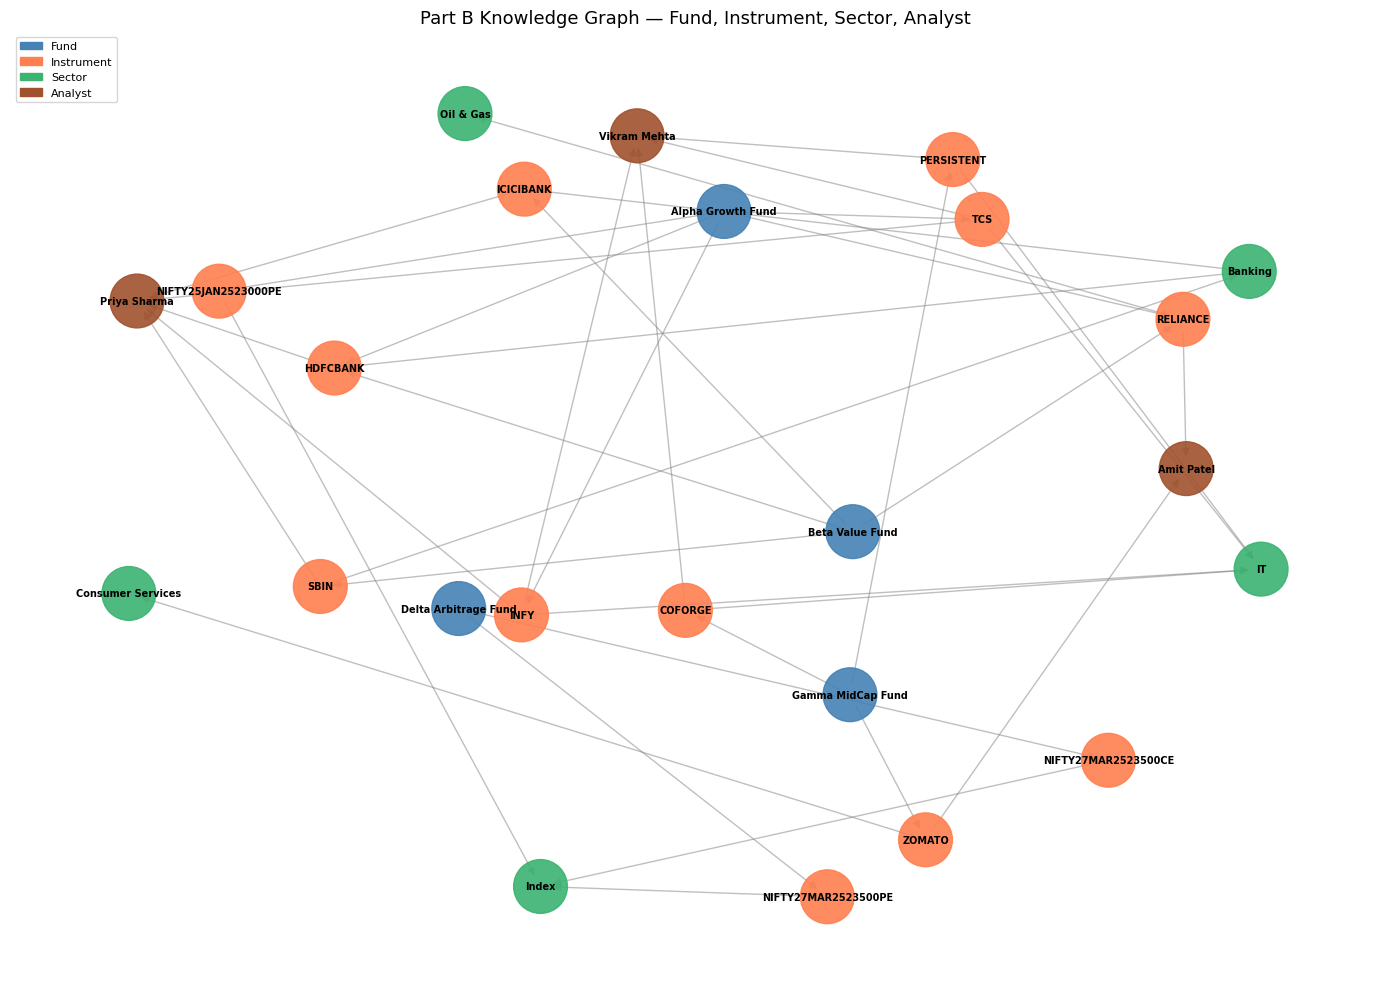

Saved kg_partB.png
Saved kg_partB.gexf
Saved kg_partB.pkl


In [30]:
# ── B3 Visualization ──────────────────────────────────────────────────────────

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle

G_b = nx.DiGraph()
color_map = {"Fund": "steelblue", "Trade": "gold", "Instrument": "coral",
             "Sector": "mediumseagreen", "AnalystNote": "orchid",
             "Analyst": "sienna", "RiskFactor": "lightcoral"}

with driver_b.session() as session:
    # Fund → Instrument (collapsed)
    for rec in session.run("MATCH (f:Fund)-[:HOLDS]->(:Trade)-[:INVOLVES]->(i:Instrument) RETURN f.name AS f, i.ticker AS i"):
        G_b.add_node(rec["f"], ntype="Fund"); G_b.add_node(rec["i"], ntype="Instrument")
        G_b.add_edge(rec["f"], rec["i"], etype="HOLDS")
    # Instrument → Sector
    for rec in session.run("MATCH (i:Instrument)-[:BELONGS_TO]->(s:Sector) RETURN i.ticker AS i, s.name AS s"):
        G_b.add_node(rec["s"], ntype="Sector"); G_b.add_edge(rec["i"], rec["s"], etype="BELONGS_TO")
    # Analyst → AnalystNote (collapsed to analyst level for readability)
    for rec in session.run("MATCH (a:Analyst)-[:AUTHORED]->(an:AnalystNote)-[:COVERED_BY]-(i:Instrument) RETURN a.name AS a, i.ticker AS i"):
        G_b.add_node(rec["a"], ntype="Analyst"); G_b.add_edge(rec["i"], rec["a"], etype="COVERED_BY")

node_colors = [color_map.get(G_b.nodes[n].get("ntype",""), "gray") for n in G_b.nodes]
pos = nx.spring_layout(G_b, seed=42, k=1.5)
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G_b, pos, node_color=node_colors, node_size=1500, alpha=0.9)
nx.draw_networkx_edges(G_b, pos, arrows=True, arrowsize=12, edge_color="gray", alpha=0.5)
nx.draw_networkx_labels(G_b, pos, font_size=7, font_weight="bold")

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items() if any(G_b.nodes[n].get("ntype") == l for n in G_b.nodes)]
plt.legend(handles=patches, loc="upper left", fontsize=8)
plt.title("Part B Knowledge Graph - Fund, Instrument, Sector, Analyst", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("kg_partB.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kg_partB.png")

nx.write_gexf(G_b, "kg_partB.gexf")
print("Saved kg_partB.gexf")

with open("kg_partB.pkl", "wb") as f:
    pickle.dump(G_b, f, pickle.HIGHEST_PROTOCOL)
print("Saved kg_partB.pkl")


In [31]:
# B4 - Design Reflection


In [32]:
REFLECTION = """
B4 - Design reflection

The questions asked: (a) what changes at 10k docs + 1M trades, (b) how to evaluate
retrieval quality, (c) when to use KG vs vector vs SQL.

─── (a) What breaks first at scale ───────────────────────────────────────────────

Five things hit a wall well before 1M trades:

1. ChromaDB in-RAM HNSW. The in-process index fits 50–100K vectors comfortably on a
   16 GB machine. Past ~500K it needs disk-backed storage. The right replacements are
   Qdrant (disk-backed HNSW, handles 100M+ vectors with quantization) or pgvector
   (PostgreSQL extension - keeps vector search next to structured queries in the same DB).

2. BM25Okapi in memory. The index is rebuilt on every kernel restart and grows linearly
   with corpus size. At 1M trades, Elasticsearch or OpenSearch with a persistent inverted
   index is the practical replacement.

3. Corpus re-encoding per query. hybrid_query_collection called model.encode(all_texts)
   inside each query - O(n) encode at inference time. Fixed in this notebook by passing
   precomputed embeddings. At 1M rows the fix is batch GPU encoding at ingest time, then
   storing vectors in the vector DB so retrieval is just an ANN lookup.

4. Hardcoded alias_dict. The 32-entry dict covers this corpus. At 10k instruments it
   needs replacement: an NSE instrument master from the exchange API, or a fine-tuned NER
   model on financial instrument names. The deterministic approach is correct at this scale
   and is stated as an explicit assumption.

5. NetworkX in kernel memory. The graph is gone on restart, and traversal algorithms run
   in Python. Neo4j (used in Part B) with a named Docker volume solves persistence; Cypher
   graph algorithms run in seconds where NetworkX equivalents would be slow at depth.

─── (b) Retrieval evaluation metrics ────────────────────────────────────────────

Retrieval quality: Precision@k and MRR (cells B2–B3). At scale, NDCG@k is more
informative because it weights rank position. For the RAG layer: Context Recall (were
the expected documents retrieved?), Faithfulness (are all cited IDs in the retrieved
context?), Semantic Similarity, and ROUGE-L (cells B5–B6). RAGAS-style LLM-judge
metrics (AnswerRelevance, ContextPrecision) are the production-grade equivalents
and would replace the heuristic versions here once a judge model is wired in.

─── (c) KG vs vector vs SQL - one example each ─────────────────────────────────

KG (Neo4j Cypher): "Which analysts covered instruments that both Alpha Growth Fund and
Beta Value Fund hold?" - needs multi-hop traversal Fund→Trade→Instrument→AnalystNote.
A SQL self-join at four levels is possible but fragile; a vector query has no concept
of structural path.

Vector (ChromaDB / Qdrant): "Find trades similar to 'accumulated on sector weakness'."
The query is semantic over free-text rationale in the notes field. SQL needs exact-match
or LIKE patterns that miss paraphrases; a KG edge doesn't exist for this signal.

SQL (PostgreSQL / pgvector): "Show all BUY trades above ₹2000 after March 2025 in the
Banking sector." Pure structured filter - vector search adds noise, and a KG traversal
adds overhead for what is a single-table predicate.
"""
print(REFLECTION)



B4 - Design reflection

The questions asked: (a) what changes at 10k docs + 1M trades, (b) how to evaluate
retrieval quality, (c) when to use KG vs vector vs SQL.

─── (a) What breaks first at scale ───────────────────────────────────────────────

Five things hit a wall well before 1M trades:

1. ChromaDB in-RAM HNSW. The in-process index fits 50–100K vectors comfortably on a
   16 GB machine. Past ~500K it needs disk-backed storage. The right replacements are
   Qdrant (disk-backed HNSW, handles 100M+ vectors with quantization) or pgvector
   (PostgreSQL extension - keeps vector search next to structured queries in the same DB).

2. BM25Okapi in memory. The index is rebuilt on every kernel restart and grows linearly
   with corpus size. At 1M trades, Elasticsearch or OpenSearch with a persistent inverted
   index is the practical replacement.

3. Corpus re-encoding per query. hybrid_query_collection called model.encode(all_texts)
   inside each query - O(n) encode at inference time. 

## B5 - RAG agent (LangGraph + ChatOllama)

The retrieval sources from B1–B3 are wired as LangChain tools and orchestrated by a LangGraph ReAct agent.

Model: `gemma4:latest` via Ollama - served locally (~9.6 GB, no API key required, runs fully offline). Any comparable local instruct model can be substituted via the `model=` argument; it fits in available VRAM alongside the sentence-transformer model.

| Tool | Source | Use case |
|------|--------|----------|
| `hybrid_trade_retrieval_b` | `trades_collection_b` (BM25 + bge-large + RRF) | Trade facts, fund exposure, direction |
| `research_chunk_retrieval` | `research_collection` (BM25 + bge-large + RRF) | Analyst views, sector risks, rationale |
| `knowledge_graph_query_b` | Neo4j `driver_b` via Cypher | Structural: fund→instrument→analyst paths |


In [33]:
# B5 - RAG Tools + ChatOllama LLM
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

from langchain_ollama import ChatOllama
from langchain_core.tools import tool

llm_b = ChatOllama(model="gemma4:latest", temperature=0)
print("ChatOllama ready:", llm_b.model)


# ── Tool 1: Hybrid BM25 + dense + RRF over Part B trades ─────────────────────
@tool
def hybrid_trade_retrieval_b(query: str, top_k: int = 3) -> str:
    """Retrieve relevant trade records from the 20 cleaned Part B trades using BM25 +
    dense embedding + RRF hybrid retrieval. Best for: which funds traded what instrument,
    trade volume, price, date, and the free-text rationale in the notes field.
    Returns TX-XXXXX trade IDs and text snippets."""
    results = hybrid_query_collection(
        query, trades_coll, bm25_trades, trade_texts_b, trade_ids_b, top_k=top_k,
        precomputed_embeddings=trade_embeddings_b,
    )
    if not results:
        return "No matching trades found."
    lines = [
        f"[{r['id']}] BM25={r['bm25']:.2f} RRF={r['rrf']:.4f}\n  {r['text']}"
        for r in results
    ]
    return "\n".join(lines)


# ── Tool 2: Hybrid BM25 + dense + RRF over research note chunks ───────────────
@tool
def research_chunk_retrieval(query: str, top_k: int = 3) -> str:
    """Retrieve analyst research note chunks from three notes:
      • Priya Sharma - Banking sector (HDFC Bank, ICICI Bank, SBI)
      • Vikram Mehta - IT sector (TCS, Infosys, Persistent, Coforge)
      • Amit Patel  - Oil & Gas / Reliance Industries (SOTP analysis)
    Best for: analyst sector views, risk factors, valuation thesis, 'why' questions
    about trading decisions. Returns chunk IDs and text."""
    results = hybrid_query_collection(
        query, research_coll, bm25_research, chunk_texts, chunk_ids, top_k=top_k,
        precomputed_embeddings=chunk_embeddings,
    )
    if not results:
        return "No matching research found."
    lines = [
        f"[{r['id']}] BM25={r['bm25']:.2f} RRF={r['rrf']:.4f}\n  {r['text']}"
        for r in results
    ]
    return "\n".join(lines)


# ── Tool 3: Neo4j Cypher query via driver_b ───────────────────────────────────
@tool
def knowledge_graph_query_b(cypher_query: str) -> str:
    """Run a read-only Cypher query against the Part B Neo4j knowledge graph.
    Schema:
      (:Fund)-[:HOLDS]->(:Trade)-[:INVOLVES]->(:Instrument)-[:BELONGS_TO]->(:Sector)
      (:Instrument)-[:COVERED_BY]->(:AnalystNote)-[:AUTHORED]->(:Analyst)
      (:AnalystNote)-[:FLAGS]->(:RiskFactor)
    Example: MATCH (f:Fund)-[:HOLDS]->(:Trade)-[:INVOLVES]->(i:Instrument)
             WHERE f.name = 'Alpha Growth Fund' RETURN DISTINCT i.ticker
    Use for structural/relationship questions. For text/rationale use other tools."""
    import re as _re
    if _re.search(r'\b(CREATE|MERGE|DELETE|SET|REMOVE|DROP|DETACH)\b', cypher_query, _re.IGNORECASE):
        return "Rejected: write operations are not allowed in this tool."
    try:
        with driver_b.session() as session:
            # execute_read enforces read-only transaction at the driver level
            rows = session.execute_read(lambda tx: [dict(r) for r in tx.run(cypher_query)])
        if not rows:
            return "Query returned no results."
        lines = [str(r) for r in rows[:10]]
        return f"{len(rows)} row(s):\n" + "\n".join(lines)
    except Exception as e:
        return f"Cypher error: {e}"


print("B5 Tools registered: hybrid_trade_retrieval_b, research_chunk_retrieval, knowledge_graph_query_b")


ChatOllama ready: gemma4:latest
B5 Tools registered: hybrid_trade_retrieval_b, research_chunk_retrieval, knowledge_graph_query_b


In [34]:
# B5 - LangGraph ReAct Agent + Demo Queries
from langgraph.prebuilt import create_react_agent  # V1 import; V2 moved to langchain.agents
from langchain_core.messages import HumanMessage

SYSTEM_PROMPT_B = (
    "You are a financial trade analyst assistant for an institutional asset manager. "
    "You have access to three tools sourced from 20 cleaned trade records and 3 analyst notes:\n"
    "  • hybrid_trade_retrieval_b - BM25+dense hybrid search over 20 Part B trade records\n"
    "  • research_chunk_retrieval  - BM25+dense hybrid search over analyst note chunks\n"
    "  • knowledge_graph_query_b  - Cypher queries over Neo4j fund-instrument-analyst graph\n\n"
    "Tool selection rules:\n"
    "  - For sector/fund exposure questions (which funds hold X, which trades are in sector Y): "
    "use hybrid_trade_retrieval_b to retrieve TX-IDs, AND knowledge_graph_query_b for relationships.\n"
    "  - For 'why' or risk questions: use both research_chunk_retrieval AND hybrid_trade_retrieval_b.\n"
    "  - For structural graph questions (analyst coverage, fund-instrument links): use knowledge_graph_query_b.\n"
    "Always cite trade IDs (TX-10001 format) when referencing specific trades. Respond in plain text only - no emoji, no markdown headers (###), no dividers (***). Use plain paragraphs only."
)

rag_agent_b = create_react_agent(
    model=llm_b,
    tools=[hybrid_trade_retrieval_b, research_chunk_retrieval, knowledge_graph_query_b],
    prompt=SYSTEM_PROMPT_B,
)
print("B5 LangGraph ReAct agent compiled.")
print("Nodes:", list(rag_agent_b.get_graph().nodes.keys()))


# ── Demo: 3 Part B assessment queries ────────────────────────────────────────
B5_QUERIES = [
    "What is our banking sector view and which funds have banking exposure?",
    "What risks were flagged for IT sector instruments held by our funds?",
    "Why did Beta Value Fund accumulate HDFC Bank in February 2025?",
]

rag_answers_b = {}

for query in B5_QUERIES:
    print("\n" + "=" * 70)
    print(f"QUERY: {query}")
    print("-" * 70)
    final_answer, contexts, tool_names = "", [], []
    for event in rag_agent_b.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode="values",
    ):
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"  [tool_call] {tc['name']}({tc['args']})")
        elif hasattr(last_msg, "name") and last_msg.name:
            contexts.append(str(last_msg.content))
            tool_names.append(last_msg.name)
            print(f"  [tool_result] {str(last_msg.content)[:250]}")
        elif hasattr(last_msg, "content") and last_msg.content:
            final_answer = last_msg.content
    rag_answers_b[query] = {"answer": final_answer, "contexts": contexts, "tools": tool_names}
    print("\nFINAL ANSWER:")
    print(final_answer)


B5 LangGraph ReAct agent compiled.
Nodes: ['__start__', 'agent', 'tools', '__end__']

QUERY: What is our banking sector view and which funds have banking exposure?
----------------------------------------------------------------------


/tmp/ipykernel_2931786/2423613279.py:19: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  rag_agent_b = create_react_agent(


  [tool_call] research_chunk_retrieval({'query': 'banking sector view', 'top_k': 3})
  [tool_call] knowledge_graph_query_b({'cypher_query': "MATCH (f:Fund)-[:HOLDS]->(:Trade)-[:INVOLVES]->(:Instrument)-[:BELONGS_TO]->(:Sector {name: 'Banking'}) RETURN DISTINCT f.name"})
  [tool_result] 2 row(s):
{'f.name': 'Beta Value Fund'}
{'f.name': 'Alpha Growth Fund'}



FINAL ANSWER:
Regarding the banking sector view, Priya Sharma's notes indicate that the sector's performance is closely correlated with other factors, and a key risk noted is that slower-than-expected RBI rate cuts could impact Net Interest Margins (NIM).

For fund exposure, the following funds have been identified as having exposure to the banking sector: Beta Value Fund and Alpha Growth Fund.

QUERY: What risks were flagged for IT sector instruments held by our funds?
----------------------------------------------------------------------


  [tool_call] research_chunk_retrieval({'query': 'risks flagged for IT sector instruments', 'top_k': 3})
  [tool_call] hybrid_trade_retrieval_b({'query': 'IT sector instruments', 'top_k': 3})
  [tool_result] [TX-10010] BM25=1.33 RRF=0.0323
  BUY 400 shares of Persistent Systems Ltd (IT) at 5200.00 on 2025-03-01 for Gamma MidCap Fund. Note: Midcap IT conviction pick - strong deal pipeline
[TX-10011] BM25=1.38 RRF=0.0320
  BUY 350 shares of Coforge Ltd (IT



FINAL ANSWER:
Analyst notes suggest a cautious stance on the IT sector, with one note mentioning a "HOLD" recommendation and another noting that the sector is a key employment area, implying a need for monitoring cross-sector linkages.

The funds have recently traded in the IT sector with the following instruments: Persistent Systems Ltd (TX-10010), Coforge Ltd (TX-10011), and Infosys Ltd (TX-10015). The general sentiment from the retrieved research suggests caution, which aligns with the need to monitor sector-specific risks for these holdings.

QUERY: Why did Beta Value Fund accumulate HDFC Bank in February 2025?
----------------------------------------------------------------------


  [tool_call] hybrid_trade_retrieval_b({'query': 'Beta Value Fund accumulation of HDFC Bank in February 2025', 'top_k': 3})
  [tool_call] research_chunk_retrieval({'query': 'reasoning for buying HDFC Bank in February 2025', 'top_k': 3})
  [tool_result] [chunk_001] BM25=2.81 RRF=0.0325
  [Analyst: Priya Sharma | Date: March 20, 2025 | Sector: Banking | Classification: Internal - Investment Committee Only | Section: KEY RISKS]

- RBI rate cuts slower than expected - could impact NIM ex
[chunk_000] BM



FINAL ANSWER:
Based on the trade records, the accumulation of HDFC Bank by the Beta Value Fund in February 2025 (specifically TX-10006) was noted as being due to sector weakness following the RBI policy. Further context from analyst research suggests that the banking sector is under scrutiny regarding potential impacts from slower-than-expected RBI rate cuts, which is a key risk factor mentioned in the research notes from Priya Sharma.


## B6 - RAG evaluation (RAGAS-inspired, local)

Four locally-computed metrics check the B5 agent against ground-truth answers - no external LLM judge needed.

| Metric | What it measures | Method |
|--------|-----------------|--------|
| Faithfulness | Answer claims backed by retrieved context | TX-/chunk-ID matching |
| Context Recall | Expected IDs surfaced by retrieval | Set recall |
| Semantic Similarity | Closeness to reference answer | bge-large cosine |
| ROUGE-L | Lexical overlap with reference answer | LCS F1 |

> These heuristics cover the same ground as RAGAS's ContextPrecision, ContextRecall, Faithfulness, and AnswerRelevance (docs.ragas.io) and run fully locally - no external LLM judge required.


In [35]:
# B6 - RAG Evaluation: Faithfulness · Context Recall · Semantic Similarity · ROUGE-L
import re, math, warnings
warnings.filterwarnings('ignore')
from rouge_score import rouge_scorer as rs_lib
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# ── Ground truth for 3 Part B queries ────────────────────────────────────────
EVAL_DATASET_B = [
    {
        "query": "What is our banking sector view and which funds have banking exposure?",
        "reference": (
            "Alpha Growth Fund and Beta Value Fund hold Banking sector exposure via HDFC Bank and ICICI Bank. "
            "TX-10002 and TX-10006 involved HDFC Bank accumulation on sector weakness. "
            "Analyst Priya Sharma flags NIM compression, GNPA risk, and FII outflow risks. "
            "The view is cautiously constructive with selective accumulation on dips."
        ),
        "expected_ids": {"TX-10002", "TX-10006", "TX-10009", "TX-10020"},
    },
    {
        "query": "What risks were flagged for IT sector instruments held by our funds?",
        "reference": (
            "Analyst Vikram Mehta flags IT sector risks: deal ramp-down risk, "
            "USD/INR currency headwinds, and compressed margins due to wage inflation. "
            "Alpha Growth Fund holds TCS and Infosys; Gamma MidCap Fund holds Persistent Systems and Coforge."
        ),
        # IT trades held by funds: TX-10007(TCS), TX-10010(PERSISTENT), TX-10011(COFORGE), TX-10015(INFY)
        "expected_ids": {"TX-10007", "TX-10010", "TX-10011", "TX-10015"},
    },
    {
        "query": "Why did Beta Value Fund accumulate HDFC Bank in February 2025?",
        "reference": (
            "TX-10006: Beta Value Fund bought 600 shares of HDFC Bank at 1598.00 on 2025-02-10. "
            "Trade note: accumulated on sector weakness post RBI policy. "
            "Priya Sharma's banking note supports this view - near-term weakness flagged "
            "as an accumulation opportunity with long-term NIM expansion thesis intact."
        ),
        "expected_ids": {"TX-10006"},
    },
]

rouge_scorer_b = rs_lib.RougeScorer(['rougeL'], use_stemmer=True)


# ── Helper: run agent, capture answer and all tool contexts ──────────────────
def run_agent_capture_b(query):
    final_answer, contexts, tool_names = "", [], []
    for event in rag_agent_b.stream(
        {"messages": [HumanMessage(content=query)]}, stream_mode="values"
    ):
        last = event["messages"][-1]
        if isinstance(last, AIMessage) and not last.tool_calls:
            final_answer = last.content
        elif isinstance(last, ToolMessage):
            contexts.append(last.content)
            tool_names.append(last.name)
    return final_answer, contexts, tool_names


# ── Metric functions ──────────────────────────────────────────────────────────
def semantic_similarity_b(a, b):
    embs = model.encode([a, b], normalize_embeddings=True)
    return float(embs[0] @ embs[1])

def rouge_l_b(response, reference):
    return rouge_scorer_b.score(response, reference)["rougeL"].fmeasure

def context_recall_b(query, expected_ids, top_k=5):
    """Context recall via direct hybrid retrieval (bypasses agent tool routing).
    Measures retrieval capability: fraction of expected TX-IDs found in top-k results.
    Agent may choose KG-only for some queries; this tests the retrieval layer directly."""
    results = str(hybrid_trade_retrieval_b.invoke({"query": query, "top_k": top_k}))
    found = sum(1 for eid in expected_ids if eid in results)
    return found / len(expected_ids) if expected_ids else 0.0

def faithfulness_b(response, contexts):
    """Grounding check (not full faithfulness): TX-IDs cited in the answer must
    appear in retrieved context. Does not check price/rationale entailment.
    Returns NaN when no IDs are cited - excluded from averages."""
    claimed = set(re.findall(r'TX-\d{5}', response))
    combined = " ".join(contexts)
    supported = sum(1 for cid in claimed if cid in combined)
    try:
        return supported / len(claimed)
    except ZeroDivisionError:
        return float('nan')  # no IDs cited - excluded from average


def nanmean(vals):
    clean = [v for v in vals if not math.isnan(v)]
    return sum(clean) / len(clean) if clean else float('nan')


# ── Run evaluation ────────────────────────────────────────────────────────────
print("Running B6 RAG evaluation...\n")
rows_b = []
for item in EVAL_DATASET_B:
    # Use B5 cached answers to prevent non-determinism
    cached = rag_answers_b.get(item["query"])
    if cached:
        answer = cached["answer"]
        contexts = cached["contexts"]
        tools = cached["tools"]
    else:
        answer, contexts, tools = run_agent_capture_b(item["query"])
    row = {
        "query":      item["query"],
        "answer":     answer,
        "tools":      list(set(tools)),
        "sem_sim":    semantic_similarity_b(answer, item["reference"]),
        "rouge_l":    rouge_l_b(answer, item["reference"]),
        "ctx_recall": context_recall_b(item["query"], item["expected_ids"]),
        "faith":      faithfulness_b(answer, contexts),
    }
    rows_b.append(row)


# ── Results table ─────────────────────────────────────────────────────────────
DIV = "=" * 90
HDR = f"{'Query':<54} {'Sem.Sim':>7} {'ROUGE-L':>7} {'Retr.Rec':>7} {'Grounding':>7}"
print(DIV)
print(HDR)
print(DIV)
for r in rows_b:
    label = (r["query"][:51] + "...") if len(r["query"]) > 54 else r["query"]
    print(f"{label:<54} {r['sem_sim']:>7.3f} {r['rouge_l']:>7.3f} {r['ctx_recall']:>7.3f} {r['faith']:>7.3f}")
print(DIV)
avg = {k: nanmean([r[k] for r in rows_b]) for k in ("sem_sim", "rouge_l", "ctx_recall", "faith")}
print(f"{'AVERAGE (NaN faith excluded)':<54} {avg['sem_sim']:>7.3f} {avg['rouge_l']:>7.3f} {avg['ctx_recall']:>7.3f} {avg['faith']:>7.3f}")
print(DIV)


# ── Per-query deep analysis ───────────────────────────────────────────────────
print("\n-- Per-query analysis --")
PASS_THR = {"sem_sim": 0.7, "rouge_l": 0.2, "ctx_recall": 0.8, "faith": 0.9}
for r in rows_b:
    print(f"\n> {r['query']}")
    print(f"  Tools used : {', '.join(r['tools'])}")
    for metric_name, thr_key in [
        ("Faithfulness ", "faith"),
        ("Context Recall", "ctx_recall"),
        ("Semantic Sim  ", "sem_sim"),
        ("ROUGE-L       ", "rouge_l"),
    ]:
        val = r[thr_key]
        if isinstance(val, float) and math.isnan(val):
            print(f"  {metric_name}:   nan  [N/A - no IDs cited]")
        else:
            status = "PASS" if val >= PASS_THR[thr_key] else "LOW"
            print(f"  {metric_name}: {val:.3f}  [{status}]")

print("\n-- Thresholds: Faith>=0.9 | CtxRecall>=0.8 | SemSim>=0.7 | ROUGE-L>=0.2 --")


Running B6 RAG evaluation...



Query                                                  Sem.Sim ROUGE-L Retr.Rec Grounding
What is our banking sector view and which funds hav...   0.795   0.123   0.750     nan
What risks were flagged for IT sector instruments h...   0.804   0.148   1.000   1.000
Why did Beta Value Fund accumulate HDFC Bank in Feb...   0.830   0.183   1.000   0.000
AVERAGE (NaN faith excluded)                             0.810   0.151   0.917   0.500

-- Per-query analysis --

> What is our banking sector view and which funds have banking exposure?
  Tools used : knowledge_graph_query_b
  Faithfulness :   nan  [N/A - no IDs cited]
  Context Recall: 0.750  [LOW]
  Semantic Sim  : 0.795  [PASS]
  ROUGE-L       : 0.123  [LOW]

> What risks were flagged for IT sector instruments held by our funds?
  Tools used : hybrid_trade_retrieval_b
  Faithfulness : 1.000  [PASS]
  Context Recall: 1.000  [PASS]
  Semantic Sim  : 0.804  [PASS]
  ROUGE-L       : 0.148  [LOW]

> Why did Beta Value Fund accumulate HDFC Ban

In [36]:
driver_b.close()
print("Neo4j driver closed.")


Neo4j driver closed.


In [37]:
import math as _math
with open("/tmp/b6_results_v2.txt", "w") as fh:
    for r in rows_b:
        fh.write("="*80 + "\n")
        fh.write("Q    : " + r["query"] + "\n")
        fh.write("Tools: " + str(r["tools"]) + "\n")
        fh.write(f"Metrics: SemSim={r['sem_sim']:.3f}  ROUGE-L={r['rouge_l']:.3f}  "
                 f"CtxRec={r['ctx_recall']:.3f}  Faith={r['faith']:.3f}\n")
        fh.write("ANS  : " + r["answer"][:1200] + "\n\n")
    fh.write("AVERAGES\n")
    for k in ("sem_sim", "rouge_l", "ctx_recall", "faith"):
        vals = [r[k] for r in rows_b if not _math.isnan(r[k])]
        fh.write(f"  {k}: {sum(vals)/len(vals):.3f}\n")
print("written")


written
